## 1. Linear Regression

In [26]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from linear_regression import LinearRegression
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_squared_error

In [27]:
X_linreg, y_linreg = make_regression(n_samples=100, n_features=1, noise=0.1, random_state=42)
X_linreg_train, X_linreg_test, y_linreg_train, y_linreg_test = train_test_split(X_linreg, y_linreg, test_size=0.2, random_state=42)

In [28]:
linreg = LinearRegression()
linreg.fit(X_linreg_train, y_linreg_train)
y_linreg_pred = linreg.predict(X_linreg_test)

skl_linreg = SklearnLinearRegression()
skl_linreg.fit(X_linreg_train, y_linreg_train)
y_skl_linreg_pred = skl_linreg.predict(X_linreg_test)

In [29]:
linreg_mse = mean_squared_error(y_linreg_test, y_linreg_pred)
skl_linreg_mse = mean_squared_error(y_linreg_test, y_skl_linreg_pred)
print(f"Custom LR MSE: {linreg_mse} vs Sklearn LR MSE: {skl_linreg_mse}")

Custom LR MSE: 0.010429078443987199 vs Sklearn LR MSE: 0.01042022265318719


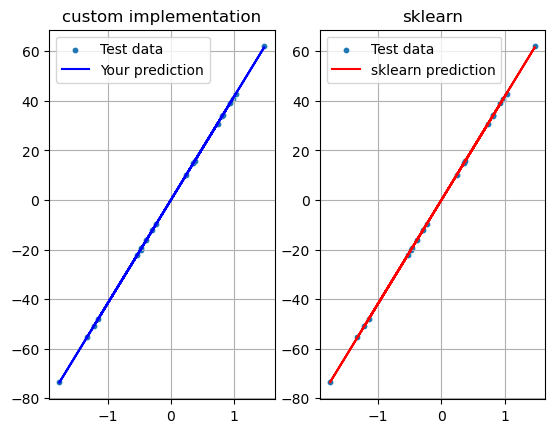

In [30]:
plt.subplot(1,2,1)
plt.scatter(X_linreg_test, y_linreg_test, s=10, label="Test data")
plt.plot(X_linreg_test, y_linreg_pred, 'b', label="Your prediction")
plt.title("custom implementation")
plt.legend()
plt.grid('on')

plt.subplot(1,2,2)
plt.scatter(X_linreg_test, y_linreg_test, s=10, label="Test data")
plt.plot(X_linreg_test, y_skl_linreg_pred, 'r', label="sklearn prediction")
plt.title("sklearn")
plt.legend()
plt.grid('on')

plt.show()

## 2. Logistic Regression

In [31]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression as SklearnLinearRegression
from log_regression import LogisticRegression


In [32]:

X_logreg, y_logreg = make_classification(n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=2, random_state=42)
X_logreg_train, X_logreg_test, y_logreg_train, y_logreg_test = train_test_split(X_logreg, y_logreg, test_size=0.2, random_state=42)


In [33]:
logreg = LogisticRegression()
logreg.fit(X_logreg_train, y_logreg_train)
y_logreg_preds = logreg.predict(X_logreg_test)


skl_logreg = SklearnLinearRegression()
skl_logreg.fit(X_logreg_train, y_logreg_train)
y_skl_logreg_preds = skl_logreg.predict(X_logreg_test)


In [34]:
def accuracy(y_true, y_pred):
    return np.mean(y_true==y_pred.ravel())*100

logreg_acc = accuracy(y_logreg_test, y_logreg_preds)
skl_logreg_acc = accuracy(y_logreg_test, y_skl_logreg_preds)

print(f"Custom logistic regression acc: {logreg_acc}\nSklearn Logistic Regression acc: {skl_logreg_acc}")

Custom logistic regression acc: 95.0
Sklearn Logistic Regression acc: 95.0


## 3. KNN

In [35]:
from sklearn.datasets import make_blobs
from knn import KNN
from sklearn.neighbors import KNeighborsClassifier

In [36]:
X_knn, y_knn = make_blobs(n_samples=200, centers=3, n_features=2, random_state=42)
X_knn_train, X_knn_test, y_knn_train, y_knn_test = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

In [37]:
knn = KNN()
knn.fit(X_knn_train, y_knn_train)
y_knn_preds = knn.predict(X_knn_test)

skl_knn = KNeighborsClassifier()
skl_knn.fit(X_knn_train, y_knn_train)
y_skl_knn_preds = skl_knn.predict(X_knn_test)


In [38]:
knn_acc = accuracy(y_knn_test, y_knn_preds)
skl_knn_acc = accuracy(y_knn_test, y_skl_knn_preds)

print(f"Custom KNN acc: {knn_acc}\nSklearn KNN acc: {skl_knn_acc}")

Custom KNN acc: 100.0
Sklearn KNN acc: 100.0


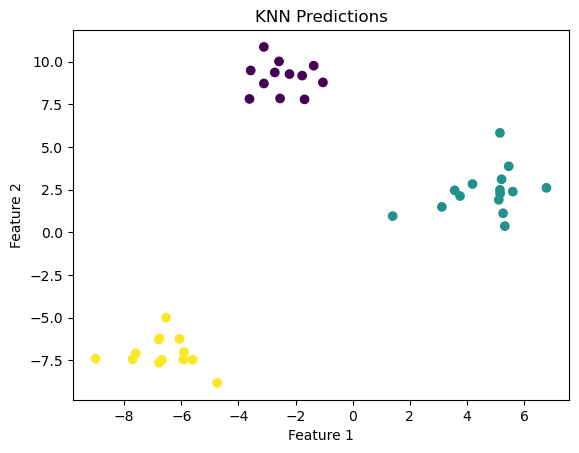

In [39]:
plt.scatter(X_knn_test[:, 0], X_knn_test[:, 1], c=y_knn_preds)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Predictions")
plt.show()

## 4. Naive Bayes

In [40]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.datasets import fetch_20newsgroups
from naive_bayes import MultinomialNB
from sklearn.naive_bayes import MultinomialNB as SklearnMultinomialNB


In [ ]:
categories = ['sci.space', 'rec.sport.hockey']
data = fetch_20newsgroups(subset='train', categories=categories)

vectorizer = CountVectorizer(max_features=1000)

# convert text to bag-of-words matrix
X = vectorizer.fit_transform(data.data).toarray()
y = np.array(data.target)

X_mnb, y_mnb = X, y
X_mnb_train, X_mnb_test, y_mnb_train, y_mnb_test = train_test_split(X_mnb, y_mnb, test_size=0.2, random_state=42)

In [42]:
mnb = MultinomialNB(alpha=1)
mnb.fit(X_mnb_train, y_mnb_train)
y_mnb_preds = mnb.predict(X_mnb_test)

skl_mnb = SklearnMultinomialNB(alpha=1)
skl_mnb.fit(X_mnb_train, y_mnb_train)
y_skl_mnb_preds = skl_mnb.predict(X_mnb_test)


In [43]:
mnb_acc = accuracy(y_mnb_test, y_mnb_preds)
skl_mnb_acc = accuracy(y_mnb_test, y_skl_mnb_preds)

print(f"Custom NB acc: {mnb_acc}\nSklearn NB acc: {skl_mnb_acc}")

Custom NB acc: 99.16317991631799
Sklearn NB acc: 99.16317991631799
